<a href="https://colab.research.google.com/github/meficnuton/ML-personal-notebooks/blob/master/MultilayerPerceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
# Display the shape of the loaded data
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

#load again if .npz file available
#Load the compressed datasets back
#loaded_data = np.load('mnist_data.npz')

#Extract the arrays from the loaded object
#x_train = loaded_data['x_train']
#y_train = loaded_data['y_train']
#x_test = loaded_data['x_test']
#y_test = loaded_data['y_test']


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


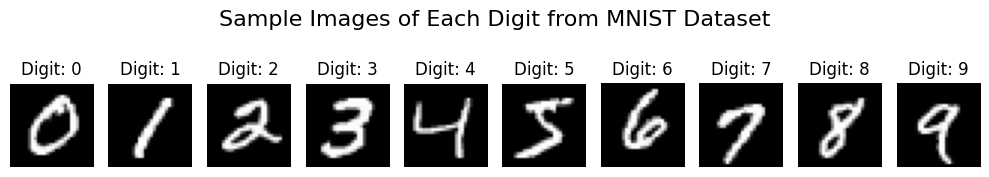

In [ ]:
import matplotlib.pyplot as plt

# Get unique digits and their indices
unique_digits = np.unique(y_train)

# Create a figure to display the sample digits
plt.figure(figsize=(10, 2))

for i, digit in enumerate(unique_digits):
    # Find the index of the first occurrence of this digit in y_train
    idx = np.where(y_train == digit)[0][0]

    # Plot the image
    plt.subplot(1, len(unique_digits), i + 1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(f"Digit: {digit}")
    plt.axis('off')

plt.suptitle('Sample Images of Each Digit from MNIST Dataset', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

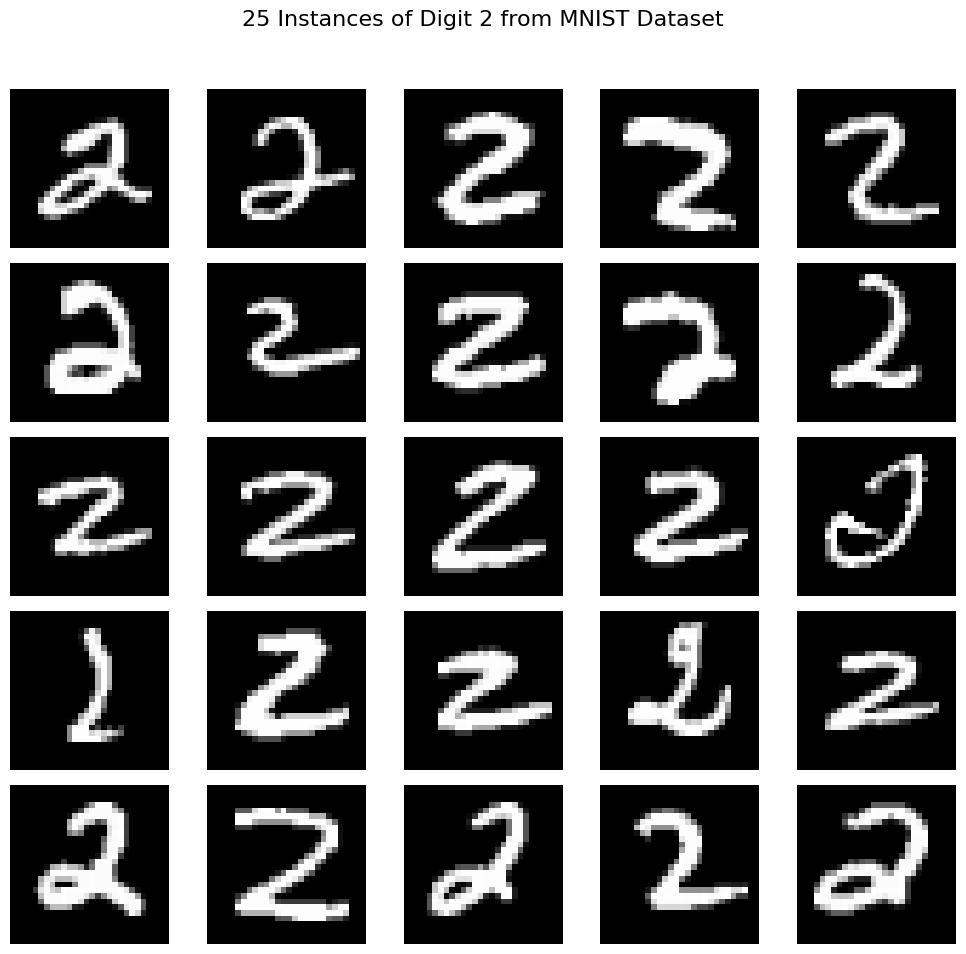

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Find indices where the digit is '2'
indices_of_2 = np.where(y_train == 2)[0]

# Take the first 25 instances of digit '2'
sample_2s = x_train[indices_of_2[:25]]

# Plot the 25 instances
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1) # 5 rows, 5 columns
    plt.imshow(sample_2s[i], cmap='gray')
    plt.axis('off')

plt.suptitle('25 Instances of Digit 2 from MNIST Dataset', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

In [ ]:
import numpy as np

# Save the datasets using np.savez_compressed
np.savez_compressed('mnist_data.npz', x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)
print("MNIST datasets saved to 'mnist_data.npz'")

MNIST datasets saved to 'mnist_data.npz'


In [ ]:
from MLP_impl import NeuralNetMLP

# Preprocess the data
# Flatten images from (28, 28) to (784,)
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# Normalize pixel values to be between 0 and 1
x_train_normalized = x_train_flat / 255.0
x_test_normalized = x_test_flat / 255.0

# Use integer labels instead of one-hot encoding, as the implementation likely handles encoding internally
# Split training data into training and validation sets
X_train_split = x_train_normalized[:55000]
y_train_split = y_train[:55000]
X_valid_split = x_train_normalized[55000:]
y_valid_split = y_train[55000:]

# Initialize and train the model
nn = NeuralNetMLP(n_hidden=100, l2=0.01, epochs=200, eta=0.0005, mini_batch_size=100, shuffle=True, seed=1)
nn.fit(X_train=X_train_split,
       y_train=y_train_split,
       X_valid=X_valid_split,
       y_valid=y_valid_split)

200/200 | Cost: 8004.06 | Train/Valid Acc.: 98.45%/97.88%

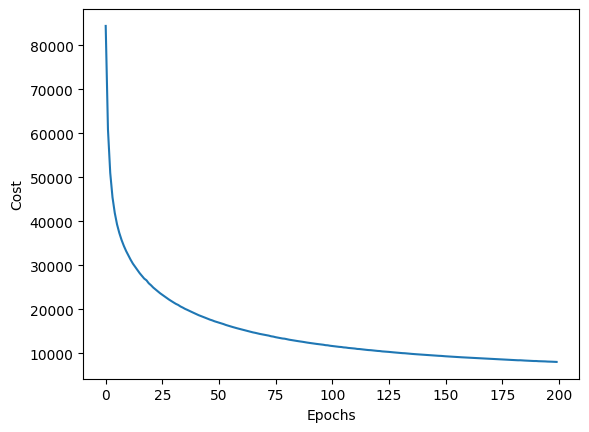

In [ ]:

plt.plot(range(nn.epochs), nn.eval_['cost'])
plt.ylabel('Cost')
plt.xlabel('Epochs')
plt.show()

In [ ]:
y_test_pred = nn.predict(x_test_normalized)
acc = (np.sum(y_test == y_test_pred) .astype(float) / x_test_normalized.shape[0])
print('Test accuracy: %.2f%%' % (acc * 100))

Test accuracy: 97.36%
